# ROOT 

In [1]:
import os
os.chdir("../../")
%pwd

'd:\\Dev\\Timeseries_Forecating\\NoteBooks'

# Libraries

pip install pandas
torch-summary
tqdm
matplotlib

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
import pandas as pd
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

from Models.LSTM.LSTM_Yahoo_Stock_Price import LSTM_YSP


# Load Dataset

In [3]:
df=pd.read_csv('Data_download\datasets\yahoo_stock.csv')
df=df.drop(columns=['Volume'])

df['Date'] = pd.to_datetime(df['Date'])
# df = df.set_index('Date')
df.head()

,Date,High,Low,Open,Close,Adj Close
0,2015-11-23,2095.610107,2081.389893,2089.409912,2086.590088,2086.590088
1,2015-11-24,2094.120117,2070.290039,2084.419922,2089.139893,2089.139893
2,2015-11-25,2093.000000,2086.300049,2089.300049,2088.870117,2088.870117
3,2015-11-26,2093.000000,2086.300049,2089.300049,2088.870117,2088.870117
4,2015-11-27,2093.290039,2084.129883,2088.820068,2090.110107,2090.110107


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1825 non-null   datetime64[ns]
 1   High       1825 non-null   float64       
 2   Low        1825 non-null   float64       
 3   Open       1825 non-null   float64       
 4   Close      1825 non-null   float64       
 5   Adj Close  1825 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 85.7 KB


# Preprocess

In [5]:
# Initialize the scaler
scaler = StandardScaler()
# Normalize the dataframe (excluding the 'Date' column)
df_normalized = df.copy()
df_normalized[df.columns[1:]] = scaler.fit_transform(df[df.columns[1:]])
df_normalized.head()

,Date,High,Low,Open,Close,Adj Close
0,2015-11-23,-1.379765,-1.364247,-1.371535,-1.378390,-1.378390
1,2015-11-24,-1.383403,-1.391708,-1.383794,-1.372128,-1.372128
2,2015-11-25,-1.386138,-1.352099,-1.371805,-1.372791,-1.372791
3,2015-11-26,-1.386138,-1.352099,-1.371805,-1.372791,-1.372791
4,2015-11-27,-1.385430,-1.357468,-1.372984,-1.369746,-1.369746


# Data Split

In [6]:
len_sequence = 14
n_future=2
x = []
y = []


In [7]:
for i in range(len(df_normalized) - (len_sequence+n_future)):
    x.append(df_normalized.iloc[i:i+len_sequence].drop(columns=['Date']).values)
    y.append(df_normalized.iloc[i+len_sequence:i+len_sequence+n_future].drop(columns=['Date']).values)

x = np.array(x)
y = np.array(y)
x_test = x[-100:]
y_test = y[-100:]
x_train = x[:-100]
y_train = y[:-100]

print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")

x shape: (1809, 14, 5)
y shape: (1809, 2, 5)
x_test shape: (100, 14, 5)
y_test shape: (100, 2, 5)
x_train shape: (1709, 14, 5)
y_train shape: (1709, 2, 5)


# Load Model

In [8]:
input_size = x_train.shape[2]
output_size = y_train.shape[2]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [9]:
Lstm_ysp_net = LSTM_YSP(input_size=input_size, output_size=output_size, device=device).to(device)
summary(Lstm_ysp_net, input_size=(len_sequence, input_size))

Layer (type:depth-idx)                   Param #
├─ModuleList: 1-1                        --
|    └─LSTMCell: 2-1                     18,176
|    └─LSTMCell: 2-2                     12,544
|    └─LSTMCell: 2-3                     3,200
|    └─LSTMCell: 2-4                     832
├─Linear: 1-2                            45
├─Linear: 1-3                            30
├─BatchNorm1d: 1-4                       16
Total params: 34,843
Trainable params: 34,843
Non-trainable params: 0


Layer (type:depth-idx)                   Param #
├─ModuleList: 1-1                        --
|    └─LSTMCell: 2-1                     18,176
|    └─LSTMCell: 2-2                     12,544
|    └─LSTMCell: 2-3                     3,200
|    └─LSTMCell: 2-4                     832
├─Linear: 1-2                            45
├─Linear: 1-3                            30
├─BatchNorm1d: 1-4                       16
Total params: 34,843
Trainable params: 34,843
Non-trainable params: 0

In [15]:
# Define the loss function and the optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(Lstm_ysp_net.parameters(), lr=0.001)
# Training loop
num_epochs = 50

avg_losses = []
epoch_loss_list = []
test_avg_loss_list=[]
test_epoch_loss_list=[]



# Datset Loader

In [11]:


# Define batch size
batch_size = 5

# Create TensorDataset and DataLoader
train_dataset = TensorDataset(torch.tensor(x_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


In [12]:
# Create TensorDataset and DataLoader
test_dataset = TensorDataset(torch.tensor(x_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

# Train Model

In [16]:

for epoch in range(num_epochs):
    loss_list = []
    test_loss_list = []
    
    Lstm_ysp_net.train()

    # Epoch-level progress bar with average loss
    with tqdm(train_loader, desc=f"Train Epoch {epoch+1}/{num_epochs}") as epoch_bar:
        cumulative_loss = 0.0

        for i, (x_batch, y_batch) in enumerate(epoch_bar, 1):
            optimizer.zero_grad()

            # Move tensors to the same device as the model
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            # Forward pass
            outputs = Lstm_ysp_net(x_batch)

            # Compute loss
            loss = criterion(outputs, y_batch)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
            # Update cumulative loss and calculate average
            cumulative_loss += loss.item()
            avg_loss = cumulative_loss / i

            # Update the progress bar
            epoch_bar.set_description(f"Train Epoch {epoch+1}/{num_epochs}")
            epoch_bar.set_postfix(Train_Loss=loss.item(), Train_Avg_Loss=avg_loss)
            

            # Append loss to loss list
            loss_list.append(loss.item())

        # Compute and log average loss for the epoch
        avg_losses.append(avg_loss)
        epoch_loss_list.append(loss_list)
    
    #Evaluation
    
    Lstm_ysp_net.eval()
    with torch.no_grad():
        
        with tqdm(test_loader, desc=f"Test Epoch {epoch+1}/{num_epochs}") as test_epoch_bar:
            
            test_cumulative_loss = 0.0
            for j,(x_batch, y_batch) in enumerate(test_epoch_bar, 1):
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = Lstm_ysp_net(x_batch)

                # Compute loss
                test_loss_fn = criterion(outputs, y_batch)        
                # Update cumulative loss and calculate average
                test_cumulative_loss += test_loss_fn.item()
                test_avg_loss = test_cumulative_loss / j
                # Update the progress bar
                
                test_epoch_bar.set_description(f"Test Epoch {epoch+1}/{num_epochs}")
                test_epoch_bar.set_postfix(Test_Loss=test_loss_fn.item(), Test_Avg_Loss=test_avg_loss)
                
                test_loss_list.append(test_loss_fn.item())
                
            test_avg_loss_list.append(test_avg_loss)
            test_epoch_loss_list.append(test_loss_list)
                

Train Epoch 1/50:   0%|          | 0/342 [00:00<?, ?it/s]

Test Epoch 50/50: 100%|██████████| 20/20 [00:00<00:00, 150.41it/s, Test_Avg_Loss=0.013, Test_Loss=0.0154]  


# Model Save

In [17]:
path = Path("artifacts/LSTM").mkdir(parents=True, exist_ok=True)

# Save path
model_save_path = os.path.join("artifacts/LSTM/", f"LSTM_YSP.pth")

# Save the model's state_dict
torch.save(Lstm_ysp_net.state_dict(), model_save_path)

print(f"Model saved to {model_save_path}")

Model saved to artifacts/LSTM/LSTM_YSP.pth


# Evaluation

## Training Loss

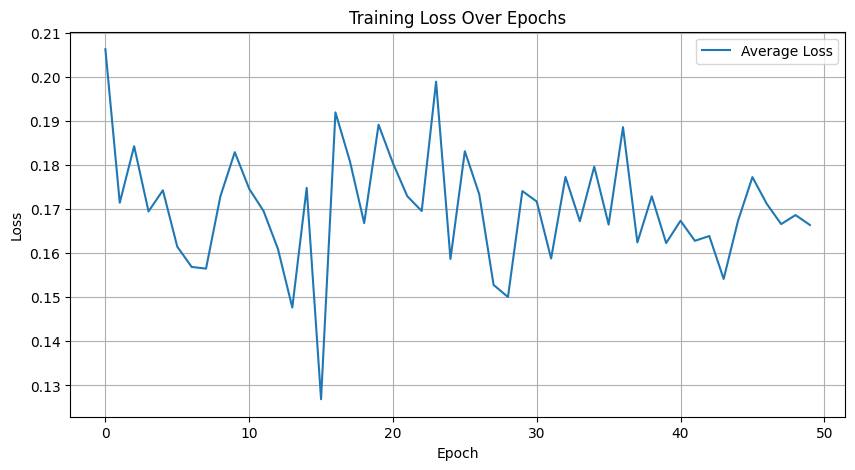

In [18]:

# Plot the average loss over epochs
plt.figure(figsize=(10, 5))
plt.plot(avg_losses, label='Average Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

## Validation loss

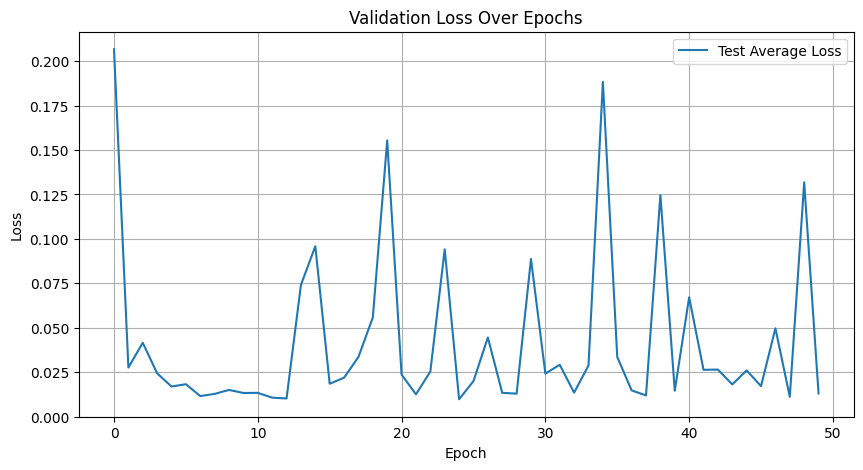

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(test_avg_loss_list,label='Test Average Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

## RSME/R2

In [90]:
Lstm_ysp_net.eval()
with torch.no_grad():
    total_test_loss = 0.0
    test_predictions=[]
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        
        outputs = Lstm_ysp_net(x_batch)
        test_predictions.append(outputs.cpu().numpy())
        


    
        

test_predictions = np.array(test_predictions)
test_predictions = test_predictions.reshape(200, 5)
y_test=y_test.reshape(200,5)

In [96]:

rmse=np.sqrt(mean_squared_error(y_test, test_predictions))

r2=r2_score(y_test, test_predictions)

# Model Load

In [20]:
model_save_path = os.path.join("artifacts/LSTM/", f"LSTM_YSP.pth")

In [21]:
# Load the model's state_dict
Lstm_ysp_net.load_state_dict(torch.load(model_save_path))

print("Model loaded successfully")

Model loaded successfully


C:\Users\User\AppData\Local\Temp\ipykernel_3644\3810503482.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  Lstm_ysp_net.load_state_dict(torch.load(model_save_path))


# Prediction
before input data to model, there should standard normalization

In [29]:
pred_df=df_normalized.iloc[-100:].copy()

In [31]:
pred_x_df=pred_df.drop(columns=['Date']).values
pred_y_day1_df=pred_df.drop(columns=['Date']).shift(-1).values
pred_y_day2_df=pred_df.drop(columns=['Date']).shift(-2).values

In [42]:
# Make predictions
Lstm_ysp_net.eval()
with torch.no_grad():
    pred_x_tensor = torch.tensor(pred_x_df, dtype=torch.float32).to(device)
    predictions=Lstm_ysp_net(pred_x_tensor[:14,:].unsqueeze(0)).cpu().numpy()


In [49]:
predictions=predictions.reshape(-1,5)

# Extract day 1 and day 2 predictions
pred_day1 = predictions[0, :]
pred_day2 = predictions[1, :]


# Extract real day 1 and day 2 values
real_day1 = pred_x_tensor[14,:]
real_day2 = pred_x_tensor[15,:]


# Move tensors to CPU and convert to numpy arrays
real_day1_cpu = real_day1.cpu().numpy()
real_day2_cpu = real_day2.cpu().numpy()

# Plot the predictions against the actual values
plt.figure(figsize=(15, 7))
plt.plot(real_day1_cpu, label='Real Day 1')
plt.plot(pred_day1, label='Predicted Day 1')
plt.plot(real_day2_cpu, label='Real Day 2')
plt.plot(pred_day2, label='Predicted Day 2')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('Stock Price Prediction: Day 1 and Day 2')
plt.legend()
plt.grid(True)
plt.show()